# POMDP Fire-Control Evaluation

POMDP v2 keeps the mixed `70/30` VAE pool as the source of plausible U-boat locations, but rebuilds firing parameters from noisy observations with `fire_control_lite`.

This tests whether a limited-information attacker can turn a plausible attack position into a usable firing solution without reusing the VAE candidate's original bearing/spread.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "convoy_sim").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from convoy_sim.feasibility import Environment
from convoy_sim.pomdp_fire_control import rebuild_records_with_fire_control, write_fire_control_candidate_pool
from convoy_sim.realism import get_attacker_observation_config
from experiments.evaluate_attack_candidate_pool import evaluate_candidate_pool, load_candidate_records
from experiments.run_pomdp_candidate_selector import run_belief_selector
from scenarios.convoy_profiles import get_convoy_layout_profile

METRIC_FIG_FACE = "lightgrey"
METRIC_AX_FACE = "white"
METRIC_GRID_COLOR = "lightgrey"


def style_metric_ax(ax, title: str, *, xlabel: str = "", ylabel: str = "", grid_axis: str = "y"):
    ax.set_title(title, fontsize=12, weight="bold")
    ax.set_facecolor(METRIC_AX_FACE)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis=grid_axis, color=METRIC_GRID_COLOR, alpha=0.45, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)


## Configuration

Defaults match the POMDP v1 evaluation so v1/v2 comparisons are meaningful. `RUN_V1_EVAL` is off by default because the v1 notebook already produced matching runs.


In [2]:
CANDIDATE_PATH = PROJECT_ROOT / "data" / "attack_profiles" / "vae_candidates" / "mixed_curated70_random30_hit_candidates.jsonl"
FULL_STATE_RUN_DIR = PROJECT_ROOT / "results" / "runs" / "candidate_pool_eval" / "20260512_144030_vae_final_baseline_mixed_vae"

OBSERVATION_PRESETS = ["good_contact", "baseline_night", "poor_contact"]
OBSERVATION_SEEDS = [1945, 1946, 1947, 1948, 1949]
MAX_PROFILES = 1000
TOP_K = 25

RUN_SELECTION = True
RUN_V1_EVAL = False
RUN_FIRE_CONTROL_REBUILD = True
RUN_FIRE_CONTROL_EVAL = True

RUN_FIXED_LOCATION_REBUILD = True
RUN_FIXED_LOCATION_EVAL = True
FIXED_LOCATION_SOURCE_PRESET = "good_contact"
FIXED_LOCATION_SOURCE_SEED = 1945

CONVOY_PROFILE = "convoy_layout_1"
EVAL_SEEDS = [1942, 1943, 1944]
N_TRIALS_PER_SEED = 10
T_MAX = 400.0
OBJECTIVE_CFG = {"preset": "balanced_default"}

OUTPUT_ROOT = Path("results/runs")
DIAG_OUTPUT_DIR = PROJECT_ROOT / "results" / "diag" / "pomdp_fire_control_eval"
CANDIDATE_POOL_DIR = DIAG_OUTPUT_DIR / "candidate_pools"
FIXED_LOCATION_POOL_DIR = DIAG_OUTPUT_DIR / "fixed_location_candidate_pools"
DIAG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CANDIDATE_POOL_DIR.mkdir(parents=True, exist_ok=True)
FIXED_LOCATION_POOL_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
preset_rows = []
for preset in OBSERVATION_PRESETS:
    cfg = get_attacker_observation_config(preset)
    row = {"preset": preset}
    row.update(cfg.to_dict())
    preset_rows.append(row)

pd.DataFrame(preset_rows)


,preset,bearing_sigma_rad,range_sigma_m,heading_sigma_rad,speed_sigma_mps,contact_count_sigma,formation_width_sigma_m,formation_depth_sigma_m,class_count_sigma,contact_detection_fraction,contact_detection_fraction_sigma
0,good_contact,0.025,80.0,0.035,0.3,0.25,100.0,120.0,0.5,0.85,0.05
1,baseline_night,0.040,120.0,0.060,0.5,0.40,180.0,200.0,0.8,0.65,0.10
2,poor_contact,0.090,300.0,0.120,1.0,1.50,450.0,500.0,1.5,0.35,0.18


## Select VAE Candidate Locations

The belief selector is reused only to choose plausible locations/context under limited observation. POMDP v2 then rebuilds firing parameters from scratch.


In [4]:
selection_runs: list[dict] = []

if RUN_SELECTION:
    for preset in OBSERVATION_PRESETS:
        for observation_seed in OBSERVATION_SEEDS:
            run_dir = run_belief_selector(
                candidate_path=CANDIDATE_PATH,
                project_root=PROJECT_ROOT,
                output_root=OUTPUT_ROOT,
                run_name=f"pomdp_v2_location_{preset}_seed{observation_seed}_notebook",
                convoy_profile=CONVOY_PROFILE,
                max_profiles=MAX_PROFILES,
                top_k=TOP_K,
                seed=int(observation_seed),
                observation_preset=preset,
            )
            selection_runs.append({
                "preset": preset,
                "observation_seed": int(observation_seed),
                "selection_dir": run_dir,
            })
            print(f"{preset} seed={observation_seed}: {run_dir}")
else:
    selection_runs = [
        # {"preset": "good_contact", "observation_seed": 1945, "selection_dir": PROJECT_ROOT / "results/runs/pomdp_candidate_selector/<existing_run>"},
    ]

pd.DataFrame(selection_runs)


good_contact seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260620_152250_pomdp_v2_location_good_contact_seed1945_notebook
good_contact seed=1946: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260620_152250_pomdp_v2_location_good_contact_seed1946_notebook
good_contact seed=1947: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260620_152250_pomdp_v2_location_good_contact_seed1947_notebook
good_contact seed=1948: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260620_152250_pomdp_v2_location_good_contact_seed1948_notebook
good_contact seed=1949: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_candidate_selector/20260620_152251_pomdp_v2_location_good_contact_seed1949_notebook
baseline_night seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/pomdp_ca

,preset,observation_seed,selection_dir
0,good_contact,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
1,good_contact,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
2,good_contact,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
3,good_contact,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
4,good_contact,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...
5,baseline_night,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
6,baseline_night,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
7,baseline_night,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
8,baseline_night,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
9,baseline_night,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...


## Rebuild Firing Solutions

For each selected location, the U-boat observes the convoy noisily and `fire_control_lite` rebuilds bearing, spread, torpedo speed, and run time. Source candidate hit/audit fields are not copied into the rebuilt records.


In [5]:
ships = get_convoy_layout_profile(CONVOY_PROFILE).build_ships()
env = Environment(time_of_day="night", visibility_m=3500.0, sea_state=4)
rebuilt_runs: list[dict] = []

if RUN_FIRE_CONTROL_REBUILD:
    for item in selection_runs:
        preset = str(item["preset"])
        observation_seed = int(item["observation_seed"])
        selected_records = load_candidate_records(item["selection_dir"] / "top_belief_candidate_pool.jsonl")
        rebuilt_records = rebuild_records_with_fire_control(
            selected_records,
            ships=ships,
            seed=observation_seed,
            env=env,
            observation_preset=preset,
            profile_id_prefix=f"POMDP_FC_{preset.upper()}_{observation_seed}",
        )
        rebuilt_path = CANDIDATE_POOL_DIR / f"pomdp_fire_control_{preset}_seed{observation_seed}.jsonl"
        write_fire_control_candidate_pool(rebuilt_path, rebuilt_records)
        rebuilt_runs.append({
            "preset": preset,
            "observation_seed": observation_seed,
            "rebuilt_candidate_path": rebuilt_path,
            "profiles": len(rebuilt_records),
        })
        print(f"{preset} seed={observation_seed}: {rebuilt_path}")
else:
    rebuilt_runs = [
        # {"preset": "good_contact", "observation_seed": 1945, "rebuilt_candidate_path": PROJECT_ROOT / "results/diag/pomdp_fire_control_eval/candidate_pools/<existing_pool>.jsonl", "profiles": TOP_K},
    ]

pd.DataFrame(rebuilt_runs)


good_contact seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/candidate_pools/pomdp_fire_control_good_contact_seed1945.jsonl
good_contact seed=1946: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/candidate_pools/pomdp_fire_control_good_contact_seed1946.jsonl
good_contact seed=1947: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/candidate_pools/pomdp_fire_control_good_contact_seed1947.jsonl
good_contact seed=1948: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/candidate_pools/pomdp_fire_control_good_contact_seed1948.jsonl
good_contact seed=1949: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/candidate_pools/pomdp_fire_control_good_contact_seed1949.jsonl
baseline_night seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval

,preset,observation_seed,rebuilt_candidate_path,profiles
0,good_contact,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
1,good_contact,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
2,good_contact,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
3,good_contact,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
4,good_contact,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
5,baseline_night,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
6,baseline_night,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
7,baseline_night,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
8,baseline_night,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
9,baseline_night,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...,25


## Evaluate POMDP v2 Fire-Control Candidates

The rebuilt profiles are evaluated with the same Monte Carlo evaluator used by v1 and the full-state oracle.


In [6]:
v2_eval_runs: list[dict] = []

if RUN_FIRE_CONTROL_EVAL:
    for item in rebuilt_runs:
        preset = str(item["preset"])
        observation_seed = int(item["observation_seed"])
        run_dir = evaluate_candidate_pool(
            candidate_path=item["rebuilt_candidate_path"],
            project_root=PROJECT_ROOT,
            output_root=OUTPUT_ROOT,
            run_name=f"pomdp_v2_fire_control_{preset}_seed{observation_seed}_top{TOP_K}_eval_notebook",
            convoy_profile=CONVOY_PROFILE,
            max_profiles=None,
            top_k=TOP_K,
            seeds=EVAL_SEEDS,
            n_trials_per_seed=N_TRIALS_PER_SEED,
            t_max=T_MAX,
            max_hits_per_torpedo=1,
            objective_cfg=OBJECTIVE_CFG,
        )
        v2_eval_runs.append({
            "selector": "pomdp_v2_fire_control",
            "preset": preset,
            "observation_seed": observation_seed,
            "eval_dir": run_dir,
        })
        print(f"{preset} seed={observation_seed}: {run_dir}")
else:
    v2_eval_runs = [
        # {"selector": "pomdp_v2_fire_control", "preset": "good_contact", "observation_seed": 1945, "eval_dir": PROJECT_ROOT / "results/runs/candidate_pool_eval/<existing_run>"},
    ]

pd.DataFrame(v2_eval_runs)


good_contact seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260620_152253_pomdp_v2_fire_control_good_contact_seed1945_top25_eval_notebook
good_contact seed=1946: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260620_152258_pomdp_v2_fire_control_good_contact_seed1946_top25_eval_notebook
good_contact seed=1947: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260620_152304_pomdp_v2_fire_control_good_contact_seed1947_top25_eval_notebook
good_contact seed=1948: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260620_152308_pomdp_v2_fire_control_good_contact_seed1948_top25_eval_notebook
good_contact seed=1949: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260620_152314_pomdp_v2_fire_control_good_contact_seed1949_top25_eval_notebook
baseline_night seed=1945: /Users/matthewplambeck/D

,selector,preset,observation_seed,eval_dir
0,pomdp_v2_fire_control,good_contact,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
1,pomdp_v2_fire_control,good_contact,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
2,pomdp_v2_fire_control,good_contact,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
3,pomdp_v2_fire_control,good_contact,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
4,pomdp_v2_fire_control,good_contact,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...
5,pomdp_v2_fire_control,baseline_night,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
6,pomdp_v2_fire_control,baseline_night,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
7,pomdp_v2_fire_control,baseline_night,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
8,pomdp_v2_fire_control,baseline_night,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
9,pomdp_v2_fire_control,baseline_night,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...


## Optional Matching POMDP v1 Evaluation

If matching v1 runs are not already available, set `RUN_V1_EVAL = True`. Otherwise this cell locates the latest existing v1 notebook runs for the same preset/seed grid.


In [7]:
v1_eval_runs: list[dict] = []

if RUN_V1_EVAL:
    for item in selection_runs:
        preset = str(item["preset"])
        observation_seed = int(item["observation_seed"])
        run_dir = evaluate_candidate_pool(
            candidate_path=item["selection_dir"] / "top_belief_candidate_pool.jsonl",
            project_root=PROJECT_ROOT,
            output_root=OUTPUT_ROOT,
            run_name=f"pomdp_v1_selected_{preset}_seed{observation_seed}_top{TOP_K}_eval_notebook",
            convoy_profile=CONVOY_PROFILE,
            max_profiles=None,
            top_k=TOP_K,
            seeds=EVAL_SEEDS,
            n_trials_per_seed=N_TRIALS_PER_SEED,
            t_max=T_MAX,
            max_hits_per_torpedo=1,
            objective_cfg=OBJECTIVE_CFG,
        )
        v1_eval_runs.append({
            "selector": "pomdp_v1_selected_profile",
            "preset": preset,
            "observation_seed": observation_seed,
            "eval_dir": run_dir,
        })
else:
    for preset in OBSERVATION_PRESETS:
        for observation_seed in OBSERVATION_SEEDS:
            matches = sorted((PROJECT_ROOT / "results" / "runs" / "candidate_pool_eval").glob(
                f"*_pomdp_{preset}_seed{observation_seed}_top{TOP_K}_eval_notebook"
            ))
            if matches:
                v1_eval_runs.append({
                    "selector": "pomdp_v1_selected_profile",
                    "preset": preset,
                    "observation_seed": int(observation_seed),
                    "eval_dir": matches[-1],
                })

pd.DataFrame(v1_eval_runs)


,selector,preset,observation_seed,eval_dir
0,pomdp_v1_selected_profile,good_contact,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
1,pomdp_v1_selected_profile,good_contact,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
2,pomdp_v1_selected_profile,good_contact,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
3,pomdp_v1_selected_profile,good_contact,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
4,pomdp_v1_selected_profile,good_contact,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...
5,pomdp_v1_selected_profile,baseline_night,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
6,pomdp_v1_selected_profile,baseline_night,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
7,pomdp_v1_selected_profile,baseline_night,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
8,pomdp_v1_selected_profile,baseline_night,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
9,pomdp_v1_selected_profile,baseline_night,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...


## Summary Tables


In [8]:
def load_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))

summary_rows = []
if FULL_STATE_RUN_DIR.exists():
    metrics = load_json(FULL_STATE_RUN_DIR / "metrics_summary.json")
    top = metrics["top_k"]
    best = metrics.get("best_candidate") or {}
    summary_rows.append({
        "selector": "full_state_oracle",
        "preset": "oracle",
        "observation_seed": -1,
        "profiles": int(top.get("profiles", TOP_K)),
        "expected_hits": float(top["expected_hits"]),
        "expected_loss": float(top.get("expected_loss", 0.0)),
        "expected_unique_ships_hit": float(top.get("expected_unique_ships_hit", 0.0)),
        "CVaR_90": float(top.get("CVaR_90", 0.0)),
        "CVaR_90_loss": float(top.get("CVaR_90_loss", 0.0)),
        "best_profile_id": str(best.get("profile_id", "")),
    })

for item in v1_eval_runs + v2_eval_runs:
    metrics = load_json(item["eval_dir"] / "metrics_summary.json")
    pool = metrics["candidate_pool"]
    best = metrics.get("best_candidate") or {}
    summary_rows.append({
        "selector": str(item["selector"]),
        "preset": str(item["preset"]),
        "observation_seed": int(item["observation_seed"]),
        "profiles": int(pool.get("profiles", TOP_K)),
        "expected_hits": float(pool["expected_hits"]),
        "expected_loss": float(pool.get("expected_loss", 0.0)),
        "expected_unique_ships_hit": float(pool.get("expected_unique_ships_hit", 0.0)),
        "CVaR_90": float(pool.get("CVaR_90", 0.0)),
        "CVaR_90_loss": float(pool.get("CVaR_90_loss", 0.0)),
        "best_profile_id": str(best.get("profile_id", "")),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,selector,preset,observation_seed,profiles,expected_hits,expected_loss,expected_unique_ships_hit,CVaR_90,CVaR_90_loss,best_profile_id
0,full_state_oracle,oracle,-1,25,3.850667,6.607333,3.180000,3.960000,6.880000,VAE000124
1,pomdp_v1_selected_profile,good_contact,1945,25,3.420000,4.164467,1.905333,3.648889,4.750655,VAE000732
2,pomdp_v1_selected_profile,good_contact,1946,25,3.450667,4.216600,1.929333,3.688889,4.684655,VAE000317
3,pomdp_v1_selected_profile,good_contact,1947,25,3.420000,3.790867,1.697333,3.688889,4.252655,VAE000732
4,pomdp_v1_selected_profile,good_contact,1948,25,3.556000,4.155933,1.888000,3.728889,4.610655,VAE000317
5,pomdp_v1_selected_profile,good_contact,1949,25,3.397333,4.151400,1.904000,3.688889,4.604655,VAE000317
6,pomdp_v1_selected_profile,baseline_night,1945,25,3.489333,3.958133,1.788000,3.728889,4.469200,VAE000459
7,pomdp_v1_selected_profile,baseline_night,1946,25,3.333333,4.230533,1.957333,3.648889,4.811200,VAE000317
8,pomdp_v1_selected_profile,baseline_night,1947,25,3.414667,3.605133,1.589333,3.640000,4.035455,VAE000317
9,pomdp_v1_selected_profile,baseline_night,1948,25,3.637333,3.876200,1.721333,3.808889,4.270655,VAE000317


In [9]:
metric_cols = ["expected_hits", "expected_loss", "expected_unique_ships_hit", "CVaR_90", "CVaR_90_loss"]
run_df = summary_df.loc[summary_df["selector"] != "full_state_oracle"].copy()
agg_df = run_df.groupby(["selector", "preset"], as_index=False)[metric_cols].agg(["mean", "std", "min", "max"])
agg_df.columns = ["selector" if col[0] == "selector" else "preset" if col[0] == "preset" else f"{col[0]}_{col[1]}" for col in agg_df.columns]
agg_df = agg_df.reset_index(drop=True)

if FULL_STATE_RUN_DIR.exists():
    oracle_row = summary_df.loc[summary_df["selector"] == "full_state_oracle"].iloc[0]
    for metric in metric_cols:
        agg_df[f"oracle_gap_{metric}"] = float(oracle_row[metric]) - agg_df[f"{metric}_mean"]

agg_df


,selector,preset,expected_hits_mean,expected_hits_std,expected_hits_min,expected_hits_max,expected_loss_mean,expected_loss_std,expected_loss_min,expected_loss_max,...,CVaR_90_max,CVaR_90_loss_mean,CVaR_90_loss_std,CVaR_90_loss_min,CVaR_90_loss_max,oracle_gap_expected_hits,oracle_gap_expected_loss,oracle_gap_expected_unique_ships_hit,oracle_gap_CVaR_90,oracle_gap_CVaR_90_loss
0,pomdp_v1_selected_profile,baseline_night,3.466133,0.112066,3.333333,3.637333,3.966827,0.248788,3.605133,4.230533,...,3.808889,4.423833,0.290798,4.035455,4.811200,0.384533,2.640507,1.388800,0.264889,2.456167
1,pomdp_v1_selected_profile,good_contact,3.448800,0.062855,3.397333,3.556000,4.095853,0.172481,3.790867,4.216600,...,3.728889,4.580655,0.192857,4.252655,4.750655,0.401867,2.511480,1.315200,0.271111,2.299345
2,pomdp_v1_selected_profile,poor_contact,3.031200,0.155608,2.818667,3.204000,3.560787,0.181069,3.325267,3.782000,...,3.450667,4.095367,0.160831,3.917206,4.271778,0.819467,3.046547,1.562667,0.607172,2.784633
3,pomdp_v2_fire_control,baseline_night,2.425067,0.176457,2.229333,2.630667,3.748493,0.299924,3.386667,4.181733,...,2.801333,4.156710,0.289674,3.776952,4.453867,1.425600,2.858840,1.388800,1.292571,2.723290
4,pomdp_v2_fire_control,good_contact,2.544000,0.137379,2.385333,2.708000,3.573627,0.154007,3.341533,3.765800,...,2.920000,3.868792,0.123646,3.667219,3.965156,1.306667,3.033707,1.500533,1.211150,3.011208
5,pomdp_v2_fire_control,poor_contact,2.269333,0.136287,2.050667,2.424000,3.997560,0.309176,3.525067,4.294333,...,2.771000,4.521109,0.335165,4.023093,4.884583,1.581333,2.609773,1.232533,1.431110,2.358891


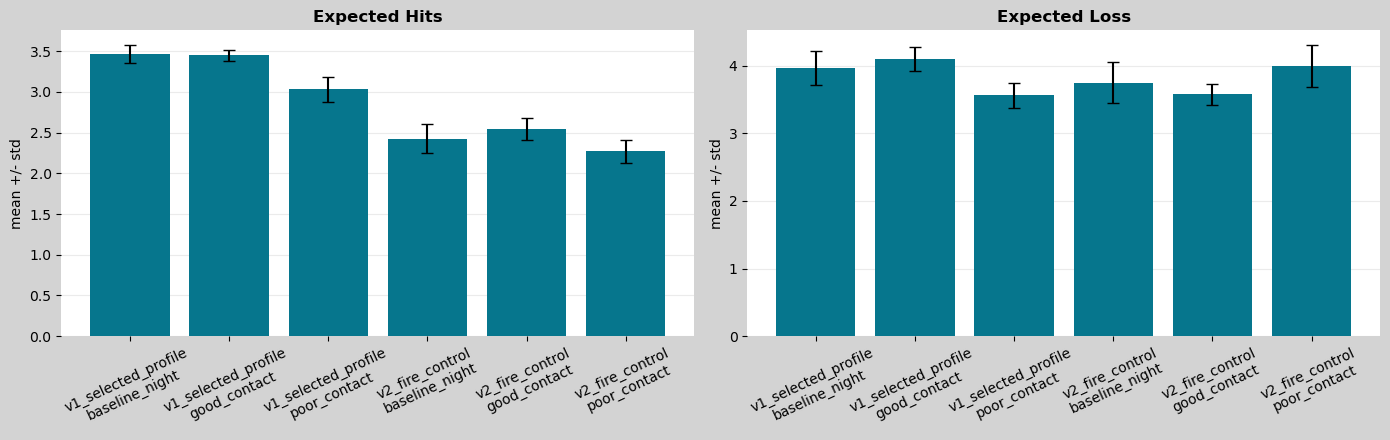

In [10]:
if len(agg_df):
    plot_df = agg_df.copy()
    plot_df["label"] = plot_df["selector"].str.replace("pomdp_", "", regex=False) + "\n" + plot_df["preset"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), facecolor=METRIC_FIG_FACE)
    axes[0].bar(plot_df["label"], plot_df["expected_hits_mean"], yerr=plot_df["expected_hits_std"], color="#06768d", capsize=4)
    style_metric_ax(axes[0], "Expected Hits", ylabel="mean +/- std")
    axes[0].tick_params(axis="x", rotation=25)
    axes[1].bar(plot_df["label"], plot_df["expected_loss_mean"], yerr=plot_df["expected_loss_std"], color="#06768d", capsize=4)
    style_metric_ax(axes[1], "Expected Loss", ylabel="mean +/- std")
    axes[1].tick_params(axis="x", rotation=25)
    plt.tight_layout()
    plt.show()


## Fixed-Location Fire-Control Diagnostic

The main v2 comparison lets each observation preset choose its own top-k locations. This diagnostic holds the selected source locations fixed, then rebuilds only the fire-control solution under each observation preset. That isolates firing-solution degradation from location-selection differences.


In [11]:
fixed_location_source = next(
    (
        item
        for item in selection_runs
        if str(item["preset"]) == str(FIXED_LOCATION_SOURCE_PRESET)
        and int(item["observation_seed"]) == int(FIXED_LOCATION_SOURCE_SEED)
    ),
    None,
)
if fixed_location_source is None:
    raise ValueError(
        "Could not find fixed-location source selection run for "
        f"{FIXED_LOCATION_SOURCE_PRESET} seed={FIXED_LOCATION_SOURCE_SEED}. "
        "Run selection first or update FIXED_LOCATION_SOURCE_PRESET / FIXED_LOCATION_SOURCE_SEED."
    )

fixed_location_source_records = load_candidate_records(fixed_location_source["selection_dir"] / "top_belief_candidate_pool.jsonl")
fixed_location_rebuilt_runs: list[dict] = []

if RUN_FIXED_LOCATION_REBUILD:
    for preset in OBSERVATION_PRESETS:
        for observation_seed in OBSERVATION_SEEDS:
            rebuilt_records = rebuild_records_with_fire_control(
                fixed_location_source_records,
                ships=ships,
                seed=int(observation_seed),
                env=env,
                observation_preset=str(preset),
                profile_id_prefix=f"POMDP_FC_FIXED_{preset.upper()}_{observation_seed}",
            )
            rebuilt_path = FIXED_LOCATION_POOL_DIR / (
                f"pomdp_fire_control_fixed_locations_from_"
                f"{FIXED_LOCATION_SOURCE_PRESET}_seed{FIXED_LOCATION_SOURCE_SEED}_"
                f"{preset}_seed{observation_seed}.jsonl"
            )
            write_fire_control_candidate_pool(rebuilt_path, rebuilt_records)
            fixed_location_rebuilt_runs.append({
                "source_preset": str(FIXED_LOCATION_SOURCE_PRESET),
                "source_observation_seed": int(FIXED_LOCATION_SOURCE_SEED),
                "preset": str(preset),
                "observation_seed": int(observation_seed),
                "rebuilt_candidate_path": rebuilt_path,
                "profiles": len(rebuilt_records),
            })
            print(f"fixed locations | {preset} seed={observation_seed}: {rebuilt_path}")
else:
    fixed_location_rebuilt_runs = [
        # {"source_preset": "good_contact", "source_observation_seed": 1945, "preset": "good_contact", "observation_seed": 1945, "rebuilt_candidate_path": PROJECT_ROOT / "results/diag/pomdp_fire_control_eval/fixed_location_candidate_pools/<existing_pool>.jsonl", "profiles": TOP_K},
    ]

pd.DataFrame(fixed_location_rebuilt_runs)


fixed locations | good_contact seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/fixed_location_candidate_pools/pomdp_fire_control_fixed_locations_from_good_contact_seed1945_good_contact_seed1945.jsonl
fixed locations | good_contact seed=1946: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/fixed_location_candidate_pools/pomdp_fire_control_fixed_locations_from_good_contact_seed1945_good_contact_seed1946.jsonl
fixed locations | good_contact seed=1947: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/fixed_location_candidate_pools/pomdp_fire_control_fixed_locations_from_good_contact_seed1945_good_contact_seed1947.jsonl
fixed locations | good_contact seed=1948: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/fixed_location_candidate_pools/pomdp_fire_control_fixed_locations_from_good_contact_seed1945_good_contact_see

,source_preset,source_observation_seed,preset,observation_seed,rebuilt_candidate_path,profiles
0,good_contact,1945,good_contact,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
1,good_contact,1945,good_contact,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
2,good_contact,1945,good_contact,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
3,good_contact,1945,good_contact,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
4,good_contact,1945,good_contact,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
5,good_contact,1945,baseline_night,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
6,good_contact,1945,baseline_night,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
7,good_contact,1945,baseline_night,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
8,good_contact,1945,baseline_night,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...,25
9,good_contact,1945,baseline_night,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...,25


## Evaluate Fixed-Location Rebuilds

These runs use the same source locations for every preset. Differences here come from noisy observation and fire-control rebuild behavior, not from the belief selector choosing different spawn regions.


In [12]:
fixed_location_eval_runs: list[dict] = []

if RUN_FIXED_LOCATION_EVAL:
    for item in fixed_location_rebuilt_runs:
        preset = str(item["preset"])
        observation_seed = int(item["observation_seed"])
        run_dir = evaluate_candidate_pool(
            candidate_path=item["rebuilt_candidate_path"],
            project_root=PROJECT_ROOT,
            output_root=OUTPUT_ROOT,
            run_name=(
                f"pomdp_v2_fixed_location_fire_control_from_{FIXED_LOCATION_SOURCE_PRESET}"
                f"_seed{FIXED_LOCATION_SOURCE_SEED}_{preset}_seed{observation_seed}"
                f"_top{TOP_K}_eval_notebook"
            ),
            convoy_profile=CONVOY_PROFILE,
            max_profiles=None,
            top_k=TOP_K,
            seeds=EVAL_SEEDS,
            n_trials_per_seed=N_TRIALS_PER_SEED,
            t_max=T_MAX,
            max_hits_per_torpedo=1,
            objective_cfg=OBJECTIVE_CFG,
        )
        fixed_location_eval_runs.append({
            "selector": "pomdp_v2_fixed_location_fire_control",
            "source_preset": str(FIXED_LOCATION_SOURCE_PRESET),
            "source_observation_seed": int(FIXED_LOCATION_SOURCE_SEED),
            "preset": preset,
            "observation_seed": observation_seed,
            "eval_dir": run_dir,
        })
        print(f"fixed locations | {preset} seed={observation_seed}: {run_dir}")
else:
    fixed_location_eval_runs = [
        # {"selector": "pomdp_v2_fixed_location_fire_control", "source_preset": "good_contact", "source_observation_seed": 1945, "preset": "good_contact", "observation_seed": 1945, "eval_dir": PROJECT_ROOT / "results/runs/candidate_pool_eval/<existing_run>"},
    ]

pd.DataFrame(fixed_location_eval_runs)


fixed locations | good_contact seed=1945: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260620_152410_pomdp_v2_fixed_location_fire_control_from_good_contact_seed1945_good_contact_seed1945_top25_eval_notebook
fixed locations | good_contact seed=1946: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260620_152415_pomdp_v2_fixed_location_fire_control_from_good_contact_seed1945_good_contact_seed1946_top25_eval_notebook
fixed locations | good_contact seed=1947: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260620_152420_pomdp_v2_fixed_location_fire_control_from_good_contact_seed1945_good_contact_seed1947_top25_eval_notebook
fixed locations | good_contact seed=1948: /Users/matthewplambeck/Desktop/Convoy Layout Project/results/runs/candidate_pool_eval/20260620_152425_pomdp_v2_fixed_location_fire_control_from_good_contact_seed1945_good_contact_seed1948_top25_eval_notebook


,selector,source_preset,source_observation_seed,preset,observation_seed,eval_dir
0,pomdp_v2_fixed_location_fire_control,good_contact,1945,good_contact,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
1,pomdp_v2_fixed_location_fire_control,good_contact,1945,good_contact,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
2,pomdp_v2_fixed_location_fire_control,good_contact,1945,good_contact,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
3,pomdp_v2_fixed_location_fire_control,good_contact,1945,good_contact,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
4,pomdp_v2_fixed_location_fire_control,good_contact,1945,good_contact,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...
5,pomdp_v2_fixed_location_fire_control,good_contact,1945,baseline_night,1945,/Users/matthewplambeck/Desktop/Convoy Layout P...
6,pomdp_v2_fixed_location_fire_control,good_contact,1945,baseline_night,1946,/Users/matthewplambeck/Desktop/Convoy Layout P...
7,pomdp_v2_fixed_location_fire_control,good_contact,1945,baseline_night,1947,/Users/matthewplambeck/Desktop/Convoy Layout P...
8,pomdp_v2_fixed_location_fire_control,good_contact,1945,baseline_night,1948,/Users/matthewplambeck/Desktop/Convoy Layout P...
9,pomdp_v2_fixed_location_fire_control,good_contact,1945,baseline_night,1949,/Users/matthewplambeck/Desktop/Convoy Layout P...


## Fixed-Location Summary

Use this table to answer whether poorer observation directly degrades fire control when the attacker starts from the same VAE-selected locations.


In [13]:
fixed_location_summary_rows = []
for item in fixed_location_eval_runs:
    metrics = load_json(item["eval_dir"] / "metrics_summary.json")
    pool = metrics["candidate_pool"]
    best = metrics.get("best_candidate") or {}
    fixed_location_summary_rows.append({
        "selector": str(item["selector"]),
        "source_preset": str(item["source_preset"]),
        "source_observation_seed": int(item["source_observation_seed"]),
        "preset": str(item["preset"]),
        "observation_seed": int(item["observation_seed"]),
        "profiles": int(pool.get("profiles", TOP_K)),
        "expected_hits": float(pool["expected_hits"]),
        "expected_loss": float(pool.get("expected_loss", 0.0)),
        "expected_unique_ships_hit": float(pool.get("expected_unique_ships_hit", 0.0)),
        "CVaR_90": float(pool.get("CVaR_90", 0.0)),
        "CVaR_90_loss": float(pool.get("CVaR_90_loss", 0.0)),
        "best_profile_id": str(best.get("profile_id", "")),
    })

fixed_location_summary_df = pd.DataFrame(fixed_location_summary_rows)
if len(fixed_location_summary_df):
    fixed_location_agg_df = fixed_location_summary_df.groupby(
        ["selector", "source_preset", "source_observation_seed", "preset"],
        as_index=False,
    )[metric_cols].agg(["mean", "std", "min", "max"])
    fixed_location_agg_df.columns = [
        "selector" if col[0] == "selector"
        else "source_preset" if col[0] == "source_preset"
        else "source_observation_seed" if col[0] == "source_observation_seed"
        else "preset" if col[0] == "preset"
        else f"{col[0]}_{col[1]}"
        for col in fixed_location_agg_df.columns
    ]
    fixed_location_agg_df = fixed_location_agg_df.reset_index(drop=True)
else:
    fixed_location_agg_df = pd.DataFrame()

fixed_location_agg_df


,selector,source_preset,source_observation_seed,preset,expected_hits_mean,expected_hits_std,expected_hits_min,expected_hits_max,expected_loss_mean,expected_loss_std,...,expected_unique_ships_hit_min,expected_unique_ships_hit_max,CVaR_90_mean,CVaR_90_std,CVaR_90_min,CVaR_90_max,CVaR_90_loss_mean,CVaR_90_loss_std,CVaR_90_loss_min,CVaR_90_loss_max
0,pomdp_v2_fixed_location_fire_control,good_contact,1945,baseline_night,2.556533,0.087684,2.445333,2.666667,3.805320,0.186707,...,1.690667,1.918667,2.778454,0.044213,2.721818,2.840000,4.194424,0.093089,4.122303,4.346615
1,pomdp_v2_fixed_location_fire_control,good_contact,1945,good_contact,2.700267,0.086304,2.620000,2.829333,3.815947,0.218575,...,1.685333,1.941333,2.906587,0.143930,2.685379,3.080000,4.074498,0.209485,3.833175,4.338067
2,pomdp_v2_fixed_location_fire_control,good_contact,1945,poor_contact,2.430133,0.111026,2.289333,2.592000,3.640080,0.163163,...,1.617333,1.833333,2.659748,0.090933,2.569333,2.801739,3.988746,0.165187,3.750000,4.123583


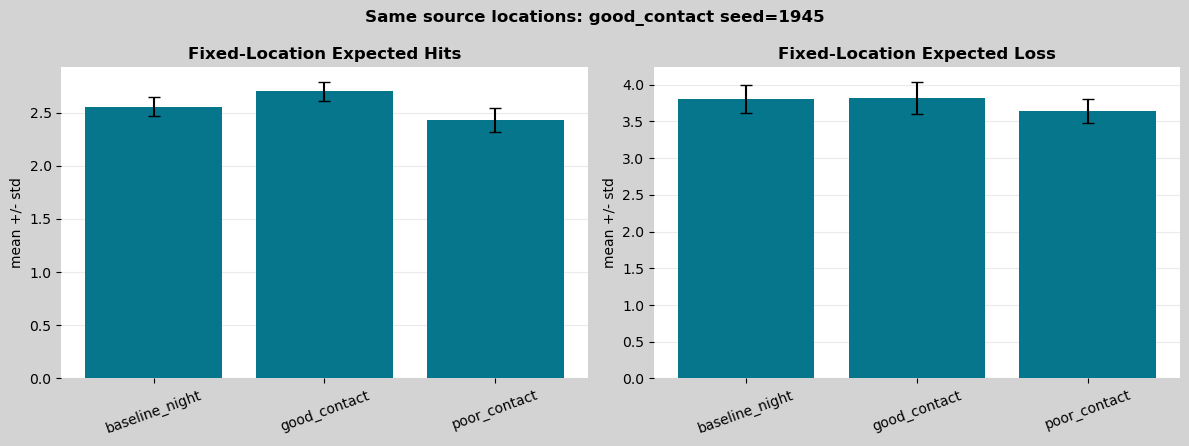

In [14]:
if len(fixed_location_agg_df):
    plot_df = fixed_location_agg_df.copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), facecolor=METRIC_FIG_FACE)
    axes[0].bar(plot_df["preset"], plot_df["expected_hits_mean"], yerr=plot_df["expected_hits_std"], color="#06768d", capsize=4)
    style_metric_ax(axes[0], "Fixed-Location Expected Hits", ylabel="mean +/- std")
    axes[0].tick_params(axis="x", rotation=20)
    axes[1].bar(plot_df["preset"], plot_df["expected_loss_mean"], yerr=plot_df["expected_loss_std"], color="#06768d", capsize=4)
    style_metric_ax(axes[1], "Fixed-Location Expected Loss", ylabel="mean +/- std")
    axes[1].tick_params(axis="x", rotation=20)
    fig.suptitle(
        f"Same source locations: {FIXED_LOCATION_SOURCE_PRESET} seed={FIXED_LOCATION_SOURCE_SEED}",
        fontsize=12,
        weight="bold",
    )
    plt.tight_layout()
    plt.show()


## Write Compact Artifacts


In [15]:
summary_csv = DIAG_OUTPUT_DIR / "pomdp_fire_control_eval_summary.csv"
per_run_csv = DIAG_OUTPUT_DIR / "pomdp_fire_control_eval_per_run.csv"
rebuilt_runs_csv = DIAG_OUTPUT_DIR / "pomdp_fire_control_rebuilt_pools.csv"
fixed_location_summary_csv = DIAG_OUTPUT_DIR / "pomdp_fire_control_fixed_location_summary.csv"
fixed_location_per_run_csv = DIAG_OUTPUT_DIR / "pomdp_fire_control_fixed_location_per_run.csv"
fixed_location_rebuilt_runs_csv = DIAG_OUTPUT_DIR / "pomdp_fire_control_fixed_location_rebuilt_pools.csv"
summary_json = DIAG_OUTPUT_DIR / "pomdp_fire_control_eval_summary.json"

agg_df.to_csv(summary_csv, index=False)
summary_df.to_csv(per_run_csv, index=False)
pd.DataFrame(rebuilt_runs).to_csv(rebuilt_runs_csv, index=False)
fixed_location_agg_df.to_csv(fixed_location_summary_csv, index=False)
fixed_location_summary_df.to_csv(fixed_location_per_run_csv, index=False)
pd.DataFrame(fixed_location_rebuilt_runs).to_csv(fixed_location_rebuilt_runs_csv, index=False)

summary_payload = {
    "workflow": "pomdp_fire_control_eval_notebook",
    "candidate_path": str(CANDIDATE_PATH.relative_to(PROJECT_ROOT)),
    "full_state_run_dir": str(FULL_STATE_RUN_DIR.relative_to(PROJECT_ROOT)),
    "top_k": int(TOP_K),
    "observation_presets": list(OBSERVATION_PRESETS),
    "observation_seeds": [int(seed) for seed in OBSERVATION_SEEDS],
    "metric_columns": list(metric_cols),
    "aggregate": json.loads(agg_df.to_json(orient="records")),
    "per_run": json.loads(summary_df.to_json(orient="records")),
    "rebuilt_runs": [
        {**item, "rebuilt_candidate_path": str(Path(item["rebuilt_candidate_path"]).relative_to(PROJECT_ROOT))}
        for item in rebuilt_runs
    ],
    "fixed_location": {
        "source_preset": str(FIXED_LOCATION_SOURCE_PRESET),
        "source_observation_seed": int(FIXED_LOCATION_SOURCE_SEED),
        "aggregate": json.loads(fixed_location_agg_df.to_json(orient="records")),
        "per_run": json.loads(fixed_location_summary_df.to_json(orient="records")),
        "rebuilt_runs": [
            {**item, "rebuilt_candidate_path": str(Path(item["rebuilt_candidate_path"]).relative_to(PROJECT_ROOT))}
            for item in fixed_location_rebuilt_runs
        ],
    },
    "artifacts": {
        "summary_csv": summary_csv.name,
        "per_run_csv": per_run_csv.name,
        "rebuilt_runs_csv": rebuilt_runs_csv.name,
        "fixed_location_summary_csv": fixed_location_summary_csv.name,
        "fixed_location_per_run_csv": fixed_location_per_run_csv.name,
        "fixed_location_rebuilt_runs_csv": fixed_location_rebuilt_runs_csv.name,
        "summary_json": summary_json.name,
    },
}
summary_json.write_text(json.dumps(summary_payload, indent=2) + "\n", encoding="utf-8")

{
    "summary_csv": str(summary_csv),
    "per_run_csv": str(per_run_csv),
    "rebuilt_runs_csv": str(rebuilt_runs_csv),
    "fixed_location_summary_csv": str(fixed_location_summary_csv),
    "fixed_location_per_run_csv": str(fixed_location_per_run_csv),
    "fixed_location_rebuilt_runs_csv": str(fixed_location_rebuilt_runs_csv),
    "summary_json": str(summary_json),
}


{'summary_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/pomdp_fire_control_eval_summary.csv',
 'per_run_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/pomdp_fire_control_eval_per_run.csv',
 'rebuilt_runs_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/pomdp_fire_control_rebuilt_pools.csv',
 'fixed_location_summary_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/pomdp_fire_control_fixed_location_summary.csv',
 'fixed_location_per_run_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/pomdp_fire_control_fixed_location_per_run.csv',
 'fixed_location_rebuilt_runs_csv': '/Users/matthewplambeck/Desktop/Convoy Layout Project/results/diag/pomdp_fire_control_eval/pomdp_fire_control_fixed_location_rebuilt_pools.csv',
 'summary_json': '/Users/matthewplambe